In [1]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image



class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path, weights_only=False)  # ← Fix for PyTorch 2.6+
            print(f"[Camera] Loaded {path}")
            if 'feat' not in data:
                print(f"⚠️  'feat' key missing in file: {path}")
                return None
            image = data['feat']
            print(f"🔍 Camera feature shape: {image.shape}")
            print(f"📄 Keys in loaded dict: {list(data.keys())}")
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.camera_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


class TorchLidarDataset:
    def __init__(self, lidar_files):
        self.lidar_files = lidar_files

    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        try:
            data = torch.load(path)
            lidar = data['feat']  # Updated to match your file format
        except Exception as e:
            print(f"[LiDAR] Error loading {path}: {e}")
            return None

        return {
            "lidar": lidar,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.lidar_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f"📷 Found {len(camera_files)} camera files in {camera_root}")
    print(f"🛰️  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f"✅ Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f"🔎 Sample camera tokens: {cam_example}")
        print(f"🔎 Sample lidar tokens: {lidar_example}")
        print("⚠️  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files


    
def main():
    camera_dir = "/data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/dataset/features_bevformer_dev/lidar_val"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    print("camera_dataset", type(camera_dataset))
    lidar_dataset = TorchLidarDataset(matched_lidar_files)

    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])

#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")

if __name__ == "__main__":
    main()


📷 Found 1982 camera files in /data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT
🛰️  Found 1982 lidar files in /home/draiman/Desktop/dataset/features_bevformer_dev/lidar_val
✅ Matched 1982 files by token
🔍 Found 1982 matched samples.
camera_dataset <class '__main__.TorchCameraDataset'>
[Camera] Loaded /data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'lidar2img_global', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 0:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([1, 256, 90, 90])
 - Token/Image ID: 000681a060c04755a1537cf83b53ba57.pt
 - Label: 1
[Camera] Loaded /data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/000868a72138448191b4092f75ed7776.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'lidar2img_global', 'img

✅ Cropped LiDAR shape: torch.Size([256, 90, 90])


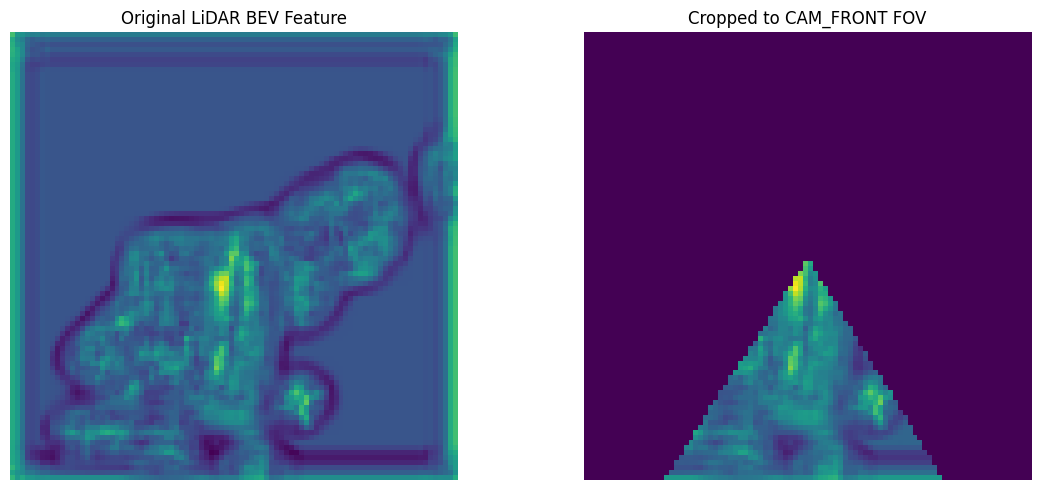

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [3]:
import torch
import os
import glob
import numpy as np


def crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range):
    """
    Crops LiDAR BEV features to the visible region of the front camera.
    
    Args:
        lidar_feat (torch.Tensor): LiDAR BEV feature map [C, H, W]
        lidar2img (np.ndarray): 4x4 lidar-to-image projection matrix
        img_shape (tuple): (H, W) of image
        bev_resolution (tuple): resolution per pixel (dx, dy)
        pc_range (list): point cloud range [x_min, y_min, z_min, x_max, y_max, z_max]
    
    Returns:
        torch.Tensor: Cropped LiDAR BEV features
    """
    C, H, W = lidar_feat.shape
    dx = (pc_range[3] - pc_range[0]) / W
    dy = (pc_range[4] - pc_range[1]) / H

    # Generate BEV coordinates
    xs = np.linspace(pc_range[0] + dx / 2, pc_range[3] - dx / 2, W)
    ys = np.linspace(pc_range[1] + dy / 2, pc_range[4] - dy / 2, H)
    xs, ys = np.meshgrid(xs, ys)
    zs = np.zeros_like(xs)

    points_lidar = np.stack([xs, ys, zs, np.ones_like(xs)], axis=-1).reshape(-1, 4)
    points_img = (lidar2img @ points_lidar.T).T
    points_img[:, 0] /= points_img[:, 2] + 1e-5
    points_img[:, 1] /= points_img[:, 2] + 1e-5

    img_w, img_h = img_shape[1], img_shape[0]
    valid = (points_img[:, 0] >= 0) & (points_img[:, 0] < img_w) & (points_img[:, 1] >= 0) & (points_img[:, 1] < img_h) & (points_img[:, 2] > 0)

    valid_mask = valid.reshape(H, W)
    valid_mask = torch.from_numpy(valid_mask).to(lidar_feat.device)

    cropped_feat = lidar_feat * valid_mask  # zero out non-visible regions
    return cropped_feat


import matplotlib.pyplot as plt

def visualize_lidar_crop(original_feat: torch.Tensor, cropped_feat: torch.Tensor):
    """
    Visualize original and cropped LiDAR BEV features as heatmaps.

    Args:
        original_feat (torch.Tensor): [C, H, W] full LiDAR BEV features
        cropped_feat (torch.Tensor): [C, H, W] cropped LiDAR BEV features
    """
    # Convert to [H, W] by averaging across channels
    original_heatmap = original_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap = cropped_feat.mean(dim=0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_heatmap, cmap='viridis')
    axes[0].set_title("Original LiDAR BEV Feature")
    axes[0].axis('off')

    axes[1].imshow(cropped_heatmap, cmap='viridis')
    axes[1].set_title("Cropped to CAM_FRONT FOV")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# # Utility function for testing with one pair of camera and LiDAR feature
# def test_crop(camera_path, lidar_path, bev_resolution, pc_range):
#     camera_data = torch.load(camera_path, weights_only=False)
#     lidar_data = torch.load(lidar_path, weights_only=False)
    

#     lidar_feat = lidar_data['feat'].squeeze(0)  # [1, C, H, W] -> [C, H, W]
#     # print("lidar_feat", lidar_feat)

#     lidar2img = camera_data['lidar2img']
#     img_shape = camera_data['img_shape']

#     cropped = crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)
#     print("✅ Cropped LiDAR shape:", cropped.shape)
#     return cropped


# # Define constants (example: CenterPoint settings)
# bev_resolution = (1.14, 1.14)  # Meters per pixel approx. for 102.4m/90px
# pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # From config

# # Replace with real paths for testing
# camera_example = "/data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
# lidar_example = "/home/draiman/Desktop/dataset/features_bevformer_dev/lidar_val/ffec010a27b4462f86b78e2e41d14f42.pt"

# # Run test
# test_crop(camera_example, lidar_example, bev_resolution, pc_range)

def test_crop(camera_path, lidar_path, bev_resolution, pc_range):
    camera_data = torch.load(camera_path, weights_only=False)
    lidar_data = torch.load(lidar_path, weights_only=False)
    
    lidar_feat = lidar_data['feat'].squeeze(0)  # [1, C, H, W] -> [C, H, W]
    lidar2img = camera_data['lidar2img']
    img_shape = camera_data['img_shape']

    cropped = crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)

    print("✅ Cropped LiDAR shape:", cropped.shape)
    visualize_lidar_crop(lidar_feat, cropped)

    return cropped


# Define constants (example: CenterPoint settings)
bev_resolution = (1.14, 1.14)  # Meters per pixel approx. for 102.4m/90px
pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # From config

# Replace with real paths for testing
camera_example = "/data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
lidar_example = "/home/draiman/Desktop/dataset/features_bevformer_dev/lidar_val/ffec010a27b4462f86b78e2e41d14f42.pt"

# Run test
test_crop(camera_example, lidar_example, bev_resolution, pc_range)


Feature shape: torch.Size([2048, 29, 50])


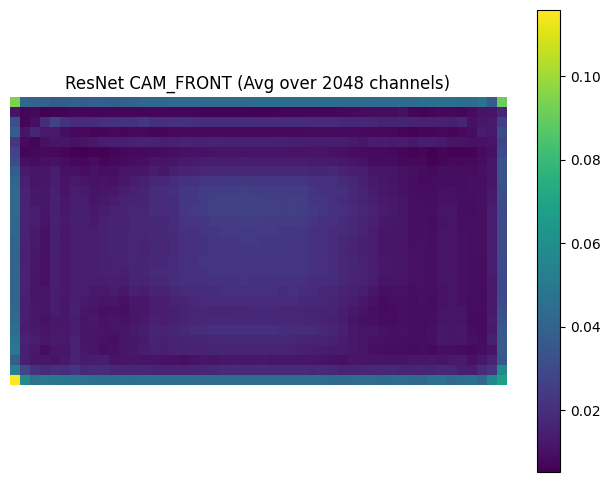

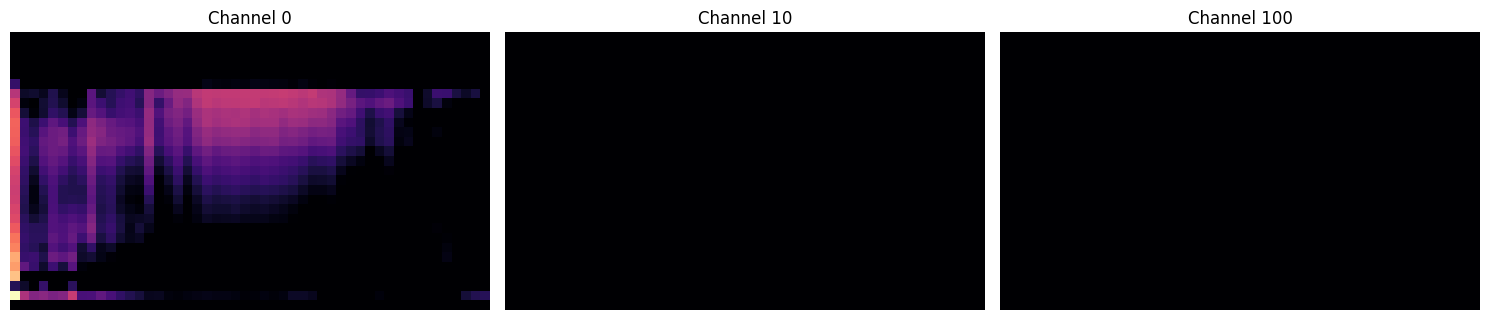

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load the feature file
feat_path = "/data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt"
data = torch.load(feat_path, weights_only=False)

feature = data['feat'].squeeze(0)  # Shape: [2048, H, W]
print("Feature shape:", feature.shape)


avg_feat = feature.mean(dim=0).cpu().numpy()  # Shape: [H, W]

plt.figure(figsize=(8, 6))
plt.imshow(avg_feat, cmap='viridis')
plt.title("ResNet CAM_FRONT (Avg over 2048 channels)")
plt.axis('off')
plt.colorbar()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ch in enumerate([0, 10, 100]):  # choose arbitrary channels
    axes[i].imshow(feature[ch].cpu(), cmap='magma')
    axes[i].set_title(f"Channel {ch}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()







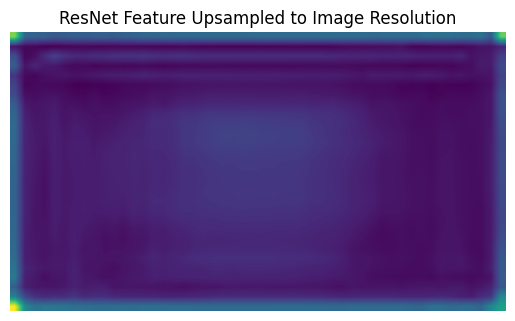

In [6]:
import torch.nn.functional as F

img_shape = data['img_shape']  # (H, W)
upsampled = F.interpolate(feature.unsqueeze(0), size=img_shape, mode='bilinear', align_corners=False)
avg_upsampled = upsampled.squeeze(0).mean(dim=0).cpu().numpy()

plt.imshow(avg_upsampled, cmap='viridis')
plt.title("ResNet Feature Upsampled to Image Resolution")
plt.axis('off')
plt.show()


In [ ]:

path_cam_front_resnet_new = "/data/nuscenes/features_bevformer_bev/resnet/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"
path_cam_front_resnet_old = "/data/lavis_my_datasets/nuscenes_dataset_multi_cam_tiny/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"







🆕 New shape: torch.Size([2048, 29, 50])
🧓 Old shape: torch.Size([2048, 29, 50])


/tmp/ipykernel_264546/3788015443.py:35: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/draiman/Desktop/Nima/LAVIS_/LAVIS/lavis-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


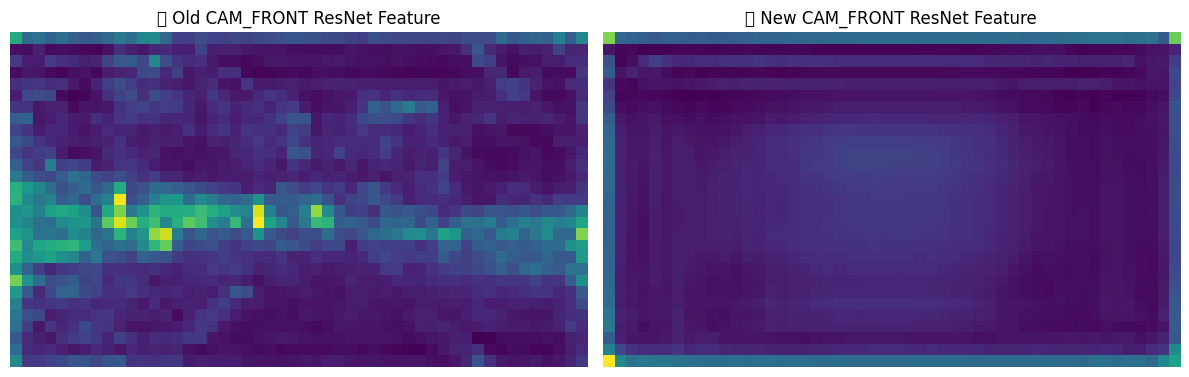

In [8]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# File paths
path_cam_front_resnet_new = "/data/nuscenes/features_bevformer_bev/resnet/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"
path_cam_front_resnet_old = "/data/lavis_my_datasets/nuscenes_dataset_multi_cam_tiny/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"

# Load features
data_new = torch.load(path_cam_front_resnet_new, weights_only=False)
data_old = torch.load(path_cam_front_resnet_old,  weights_only=False)

feat_new = data_new['feat'].squeeze(0)  # [C, H, W]
feat_old = data_old['feat'].squeeze(0)

# Optional: confirm shapes
print("🆕 New shape:", feat_new.shape)
print("🧓 Old shape:", feat_old.shape)

# Average across channels
avg_new = feat_new.mean(dim=0).cpu().numpy()
avg_old = feat_old.mean(dim=0).cpu().numpy()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(avg_old, cmap='viridis')
axes[0].set_title("📷 Old CAM_FRONT ResNet Feature")
axes[0].axis('off')

axes[1].imshow(avg_new, cmap='viridis')
axes[1].set_title("📷 New CAM_FRONT ResNet Feature")
axes[1].axis('off')

plt.tight_layout()
plt.show()


🆕 New shape: torch.Size([2048, 29, 50])
🧓 Old shape: torch.Size([2048, 29, 50])


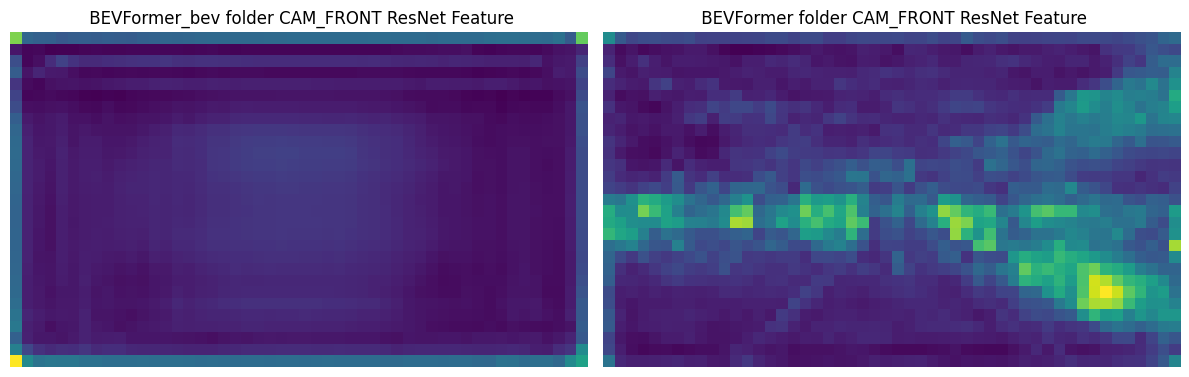

In [11]:

import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# File paths

resnet_BEVFormer_folder = "/data/features_bevformer_bev/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"

resnet_bev_folder = "/data/nuscenes/features_bevformer_bev/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
path_cam_front_resnet_new = "/data/nuscenes/features_bevformer_bev/resnet/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"
path_cam_front_resnet_old = "/data/lavis_my_datasets/nuscenes_dataset_multi_cam_tiny/train/CAM_FRONT/018544073581453fa7369ad7063135bf.pt"

# Load features
data_BEVFor = torch.load(resnet_BEVFormer_folder, weights_only=False)
data_bev = torch.load(resnet_bev_folder,  weights_only=False)

feat_BEVFor = data_BEVFor['feat'].squeeze(0)  # [C, H, W]
feat_bev = data_bev['feat'].squeeze(0)

# Optional: confirm shapes
print("🆕 New shape:", feat_BEVFor.shape)
print("🧓 Old shape:", feat_bev.shape)

# Average across channels
avg_BEVFor = feat_BEVFor.mean(dim=0).cpu().numpy()
avg_bev = feat_bev.mean(dim=0).cpu().numpy()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(avg_bev, cmap='viridis')
axes[0].set_title(" BEVFormer_bev folder CAM_FRONT ResNet Feature")
axes[0].axis('off')

axes[1].imshow(avg_BEVFor, cmap='viridis')
axes[1].set_title(" BEVFormer folder CAM_FRONT ResNet Feature")
axes[1].axis('off')

plt.tight_layout()
plt.show()



📷 Found 1982 camera files in /home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT
🛰️  Found 1982 lidar files in /home/draiman/Desktop/Datasets/validation/lidar_val
✅ Matched 1982 files by token
🔍 Found 1982 matched samples.
camera_dataset <class '__main__.TorchCameraDataset'>
[Camera] Loaded /home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 0:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000681a060c04755a1537cf83b53ba57
 - Label: 1


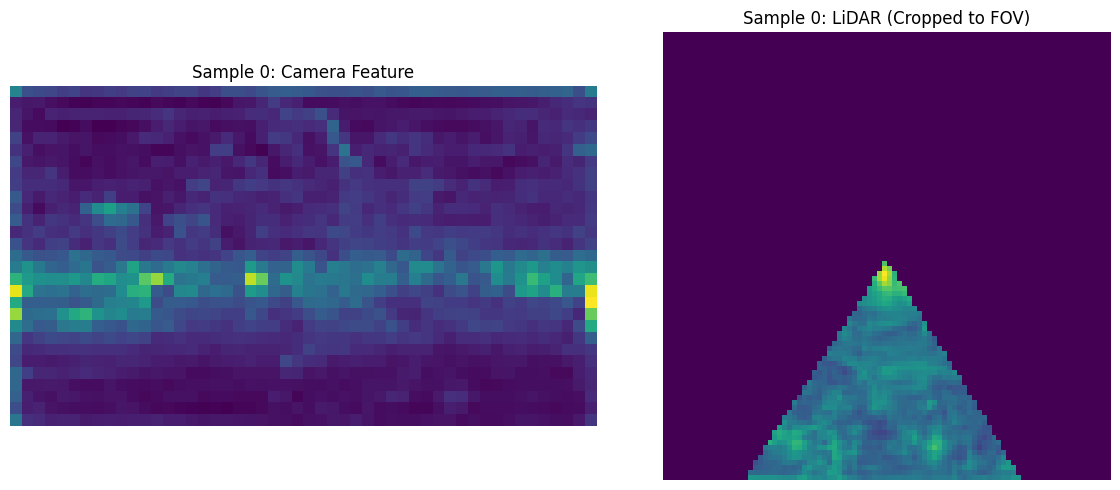

[Camera] Loaded /home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/000868a72138448191b4092f75ed7776.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 1:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000868a72138448191b4092f75ed7776
 - Label: 1


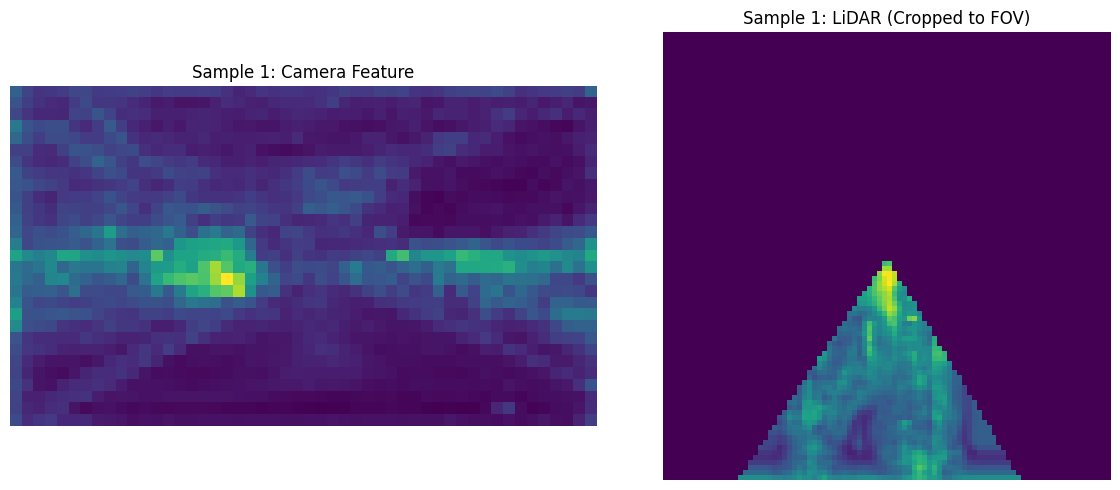

[Camera] Loaded /home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/005d3e821c4e4e0ab03f1ea1dcbf9cc8.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 2:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 005d3e821c4e4e0ab03f1ea1dcbf9cc8
 - Label: 1


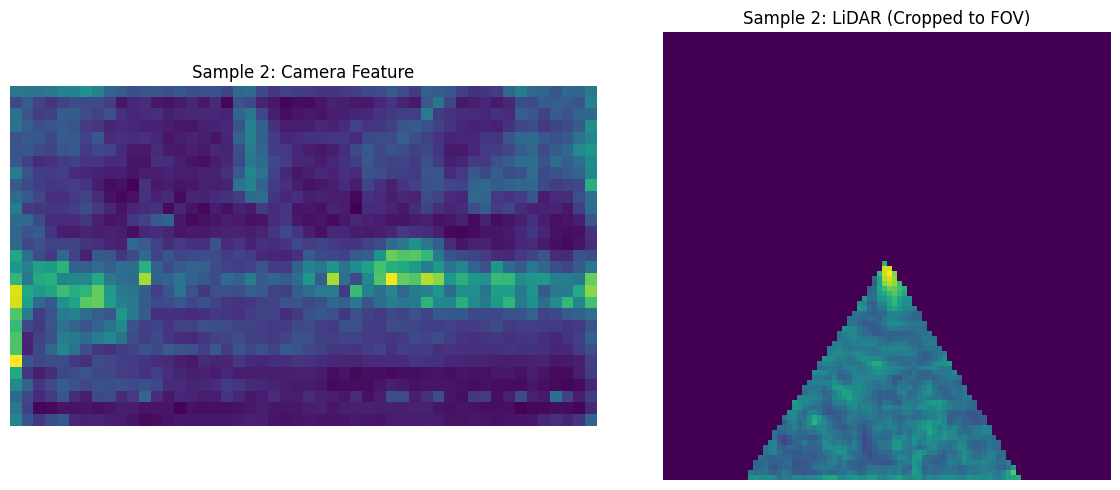

In [25]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import torch


class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path, weights_only=False)  # ← Fix for PyTorch 2.6+
            print(f"[Camera] Loaded {path}")
            if 'feat' not in data:
                print(f"⚠️  'feat' key missing in file: {path}")
                return None
            image = data['feat']
            print(f"🔍 Camera feature shape: {image.shape}")
            print(f"📄 Keys in loaded dict: {list(data.keys())}")
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.camera_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


# class TorchLidarDataset:
#     def __init__(self, lidar_files):
#         self.lidar_files = lidar_files

#     def __getitem__(self, idx):
#         path = self.lidar_files[idx]
#         try:
#             data = torch.load(path)
#             lidar = data['feat']  # Updated to match your file format
#         except Exception as e:
#             print(f"[LiDAR] Error loading {path}: {e}")
#             return None

#         return {
#             "lidar": lidar,
#             "image_id": os.path.basename(path)
#         }

#     def __len__(self):
#         return len(self.lidar_files)

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         return {
#             k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
#             for k in samples[0]
#         }


class TorchLidarDataset:
    def __init__(self, lidar_files, camera_root, bev_resolution, pc_range):
        self.lidar_files = lidar_files
        self.camera_root = camera_root
        self.bev_resolution = bev_resolution
        self.pc_range = pc_range

    def __len__(self):
        return len(self.lidar_files)
 
    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        sample_id = os.path.splitext(os.path.basename(path))[0]
        camera_path = os.path.join(self.camera_root, f"{sample_id}.pt")

        try:
            lidar_data = torch.load(path)
            lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]

            # Load camera data
            camera_data = torch.load(camera_path)
            lidar2img = camera_data['lidar2img']
            img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)

            # Crop using your existing function
            cropped_feat = crop_lidar_bev_to_camera_fov(
                lidar_feat, lidar2img, img_shape, self.bev_resolution, self.pc_range
            )

        except Exception as e:
            print(f"[LiDAR] Error loading {path} or {camera_path}: {e}")
            return None

        return {
            "lidar": cropped_feat,
            "image_id": sample_id
        }



class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f" Found {len(camera_files)} camera files in {camera_root}")
    print(f"  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f" Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f" Sample camera tokens: {cam_example}")
        print(f" Sample lidar tokens: {lidar_example}")
        print("  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files



def visualize_sample(sample, title_prefix=""):
    """
    Visualize camera feature heatmap and cropped LiDAR BEV feature heatmap.
    Args:
        sample (dict): Must contain 'image', 'lidar', and 'image_id'
    """
    cam_feat = sample['image'].squeeze(0).mean(dim=0).cpu().numpy()  # [H, W]
    lidar_feat = sample['lidar'].mean(dim=0).cpu().numpy()           # [H, W]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cam_feat, cmap='viridis')
    axes[0].set_title(f"{title_prefix}Camera Feature")
    axes[0].axis('off')

    axes[1].imshow(lidar_feat, cmap='viridis')
    axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    
def main():
    camera_dir = "/home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets/validation/lidar_val"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    print("camera_dataset", type(camera_dataset))
    # lidar_dataset = TorchLidarDataset(matched_lidar_files)
    lidar_dataset = TorchLidarDataset(
    matched_lidar_files,
    camera_root=camera_dir,
    bev_resolution=(1.14, 1.14),  # ← Adjust if needed
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    sample = None
#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
    
      # 🔍 Visualize it
        visualize_sample(sample, title_prefix=f"Sample {i}: ")
    
if __name__ == "__main__":
    main()


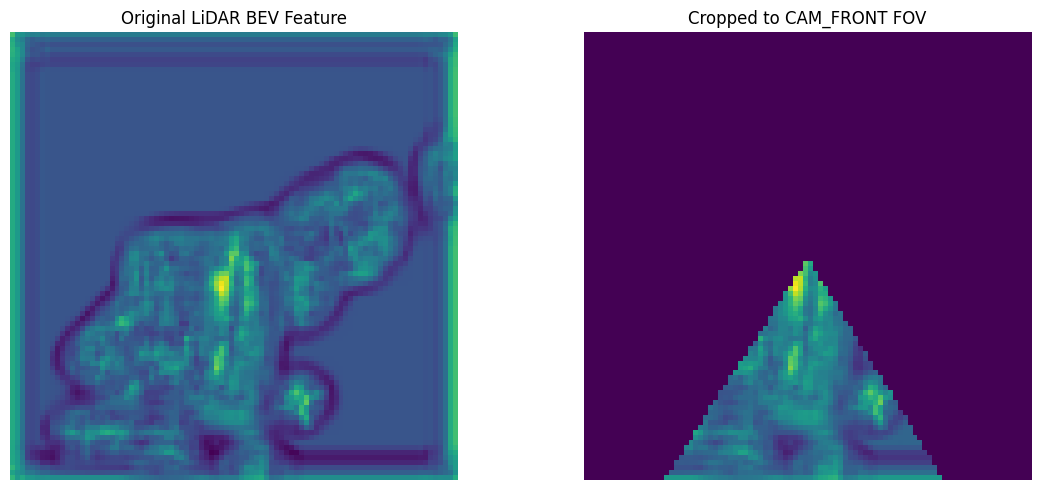

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [21]:
import torch
import os
import glob
import numpy as np


def crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range):
    """
    Crops LiDAR BEV features to the visible region of the front camera.
    
    Args:
        lidar_feat (torch.Tensor): LiDAR BEV feature map [C, H, W]
        lidar2img (np.ndarray): 4x4 lidar-to-image projection matrix
        img_shape (tuple): (H, W) of image
        bev_resolution (tuple): resolution per pixel (dx, dy)
        pc_range (list): point cloud range [x_min, y_min, z_min, x_max, y_max, z_max]
    
    Returns:
        torch.Tensor: Cropped LiDAR BEV features
    """
    C, H, W = lidar_feat.shape
    dx = (pc_range[3] - pc_range[0]) / W
    dy = (pc_range[4] - pc_range[1]) / H

    # Generate BEV coordinates
    xs = np.linspace(pc_range[0] + dx / 2, pc_range[3] - dx / 2, W)
    ys = np.linspace(pc_range[1] + dy / 2, pc_range[4] - dy / 2, H)
    xs, ys = np.meshgrid(xs, ys)
    zs = np.zeros_like(xs)

    points_lidar = np.stack([xs, ys, zs, np.ones_like(xs)], axis=-1).reshape(-1, 4)
    points_img = (lidar2img @ points_lidar.T).T
    points_img[:, 0] /= points_img[:, 2] + 1e-5
    points_img[:, 1] /= points_img[:, 2] + 1e-5

    img_w, img_h = img_shape[1], img_shape[0]
    valid = (points_img[:, 0] >= 0) & (points_img[:, 0] < img_w) & (points_img[:, 1] >= 0) & (points_img[:, 1] < img_h) & (points_img[:, 2] > 0)

    valid_mask = valid.reshape(H, W)
    # valid_mask = torch.from_numpy(valid_mask).to(lidar_feat.device)
    if isinstance(valid_mask, torch.Tensor):
        valid_mask = valid_mask.to(lidar_feat.device)
    else:
        valid_mask = torch.from_numpy(valid_mask).to(lidar_feat.device)

    cropped_feat = lidar_feat * valid_mask  # zero out non-visible regions
    return cropped_feat


import matplotlib.pyplot as plt

def visualize_lidar_crop(original_feat: torch.Tensor, cropped_feat: torch.Tensor):
    """
    Visualize original and cropped LiDAR BEV features as heatmaps.

    Args:
        original_feat (torch.Tensor): [C, H, W] full LiDAR BEV features
        cropped_feat (torch.Tensor): [C, H, W] cropped LiDAR BEV features
    """
    # Convert to [H, W] by averaging across channels
    original_heatmap = original_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap = cropped_feat.mean(dim=0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_heatmap, cmap='viridis')
    axes[0].set_title("Original LiDAR BEV Feature")
    axes[0].axis('off')

    axes[1].imshow(cropped_heatmap, cmap='viridis')
    axes[1].set_title("Cropped to CAM_FRONT FOV")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

def test_crop(camera_path, lidar_path, bev_resolution, pc_range):
    camera_data = torch.load(camera_path, weights_only=False)
    lidar_data = torch.load(lidar_path, weights_only=False)
    lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]
    lidar2img = camera_data['lidar2img']
    img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)
    
    cropped = crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)


    print("✅ Cropped LiDAR shape:", cropped.shape)
    visualize_lidar_crop(lidar_feat, cropped)

    return cropped


# Define constants (example: CenterPoint settings)
bev_resolution = (1.14, 1.14)  # Meters per pixel approx. for 102.4m/90px
pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # From config

# Replace with real paths for testing
camera_example = "/home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
lidar_example = "/home/draiman/Desktop/Datasets/validation/lidar_val/ffec010a27b4462f86b78e2e41d14f42.pt"

# Run test
test_crop(camera_example, lidar_example, bev_resolution, pc_range)


Image shape: [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)] <class 'list'>


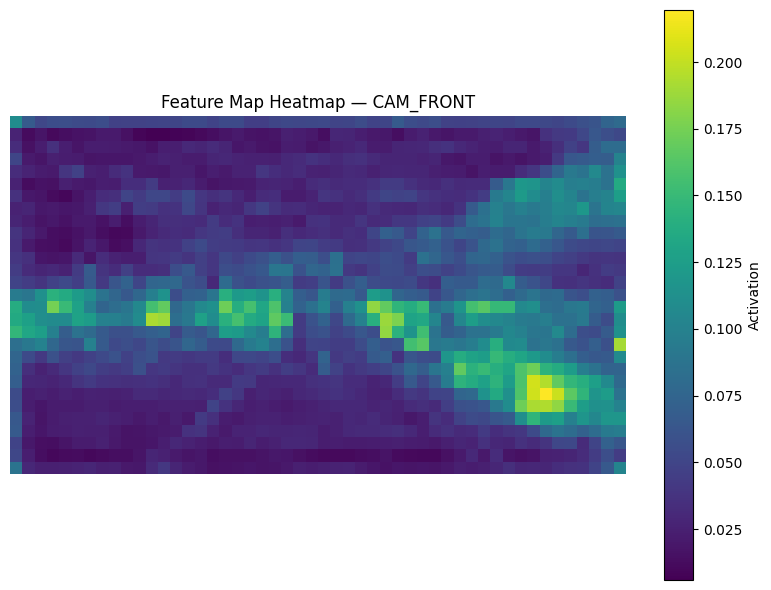

In [15]:
import torch
import matplotlib.pyplot as plt
import os

# Path to your .pt file
camera_example = "/home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"

# Load the file
camera_data = torch.load(camera_example, map_location='cpu')

# Extract and preprocess features
feat = camera_data['feat'].squeeze(0)  # shape becomes [C, H, W]
heatmap = feat.mean(dim=0).numpy()     # average over channels → shape [H, W]
print("Image shape:", camera_data['img_shape'], type(camera_data['img_shape']))
# Plotting
plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='viridis')
plt.title(f"Feature Map Heatmap — {camera_data.get('cam_name', 'Unknown Camera')}")
plt.axis('off')
plt.colorbar(label="Activation")
plt.tight_layout()
plt.show()


 Found 1982 camera files in /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT
  Found 1982 lidar files in /home/draiman/Desktop/Datasets_nuscenes/validation/lidar
 Matched 1982 files by token
🔍 Found 1982 matched samples.
camera_dataset <class '__main__.TorchCameraDataset'>
[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 0:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000681a060c04755a1537cf83b53ba57
 - Label: 1


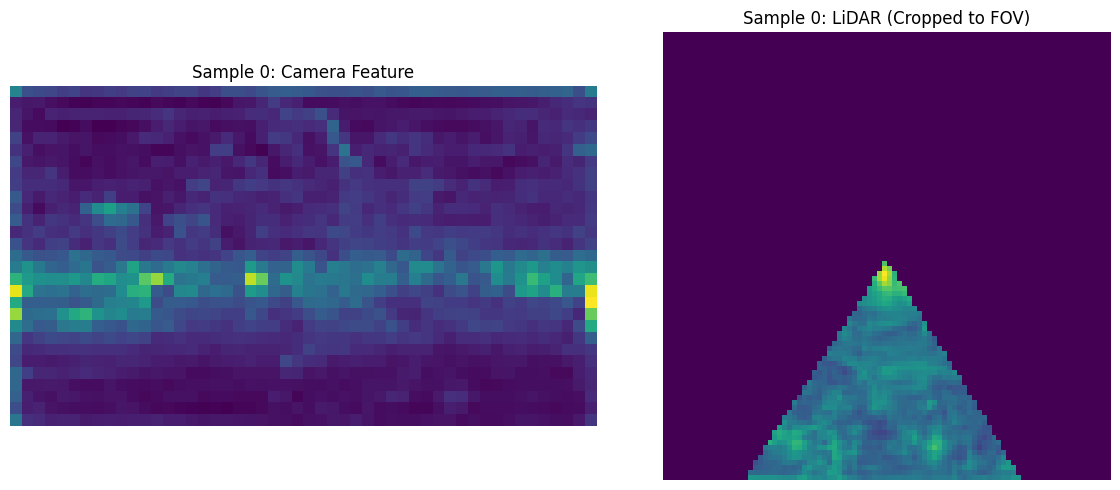

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/000868a72138448191b4092f75ed7776.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 1:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000868a72138448191b4092f75ed7776
 - Label: 1


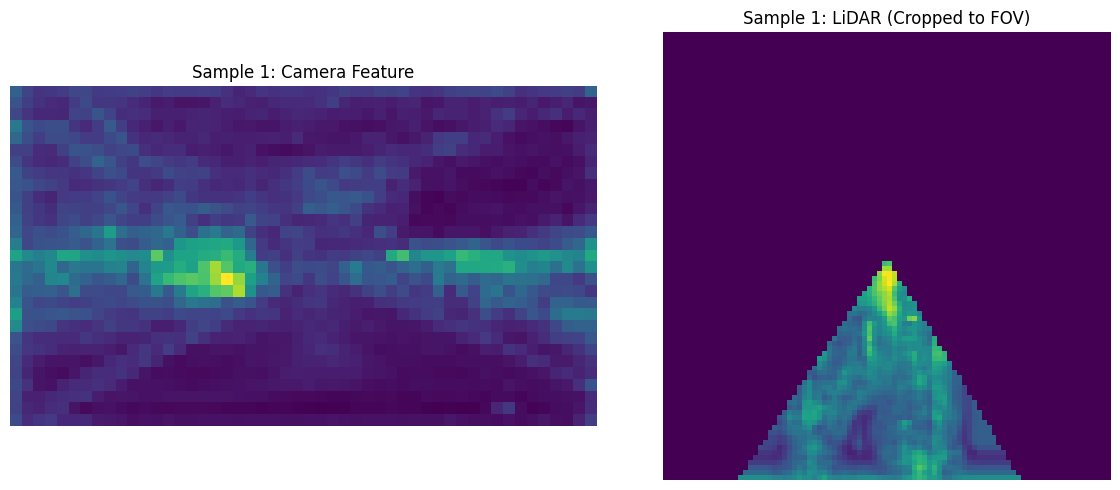

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/005d3e821c4e4e0ab03f1ea1dcbf9cc8.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 2:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 005d3e821c4e4e0ab03f1ea1dcbf9cc8
 - Label: 1


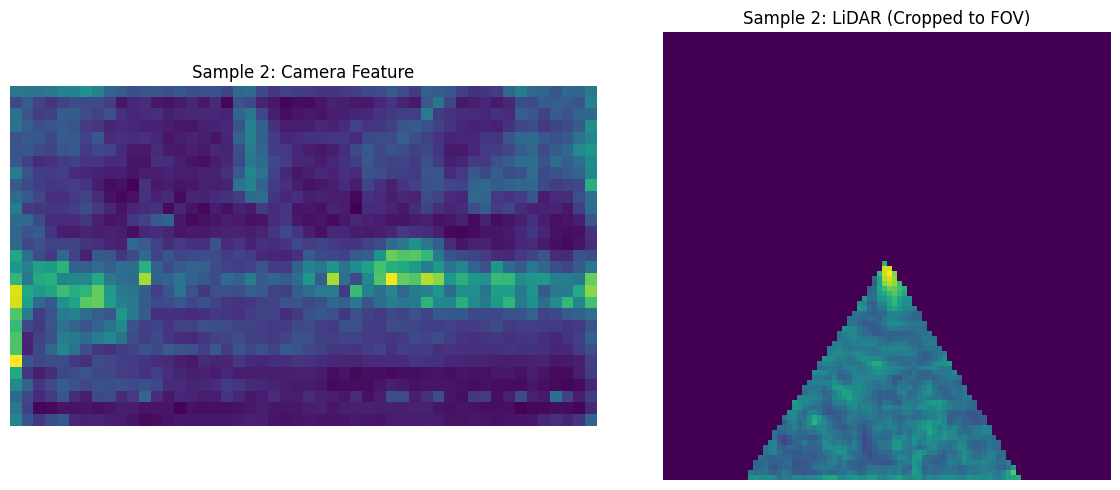

In [7]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import torch


class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path, weights_only=False)  # ← Fix for PyTorch 2.6+
            print(f"[Camera] Loaded {path}")
            if 'feat' not in data:
                print(f"⚠️  'feat' key missing in file: {path}")
                return None
            image = data['feat']
            print(f"🔍 Camera feature shape: {image.shape}")
            print(f"📄 Keys in loaded dict: {list(data.keys())}")
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.camera_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


# class TorchLidarDataset:
#     def __init__(self, lidar_files):
#         self.lidar_files = lidar_files

#     def __getitem__(self, idx):
#         path = self.lidar_files[idx]
#         try:
#             data = torch.load(path)
#             lidar = data['feat']  # Updated to match your file format
#         except Exception as e:
#             print(f"[LiDAR] Error loading {path}: {e}")
#             return None

#         return {
#             "lidar": lidar,
#             "image_id": os.path.basename(path)
#         }

#     def __len__(self):
#         return len(self.lidar_files)

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         return {
#             k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
#             for k in samples[0]
#         }


class TorchLidarDataset:
    def __init__(self, lidar_files, camera_root, bev_resolution, pc_range):
        self.lidar_files = lidar_files
        self.camera_root = camera_root
        self.bev_resolution = bev_resolution
        self.pc_range = pc_range

    def __len__(self):
        return len(self.lidar_files)
 
    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        sample_id = os.path.splitext(os.path.basename(path))[0]
        camera_path = os.path.join(self.camera_root, f"{sample_id}.pt")

        try:
            lidar_data = torch.load(path)
            lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]

            # Load camera data
            camera_data = torch.load(camera_path)
            lidar2img = camera_data['lidar2img']
            img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)

            # Crop using your existing function
            cropped_feat = crop_lidar_bev_to_camera_fov(
                lidar_feat, lidar2img, img_shape, self.bev_resolution, self.pc_range
            )

        except Exception as e:
            print(f"[LiDAR] Error loading {path} or {camera_path}: {e}")
            return None

        return {
            "lidar": cropped_feat,
            "image_id": sample_id
        }



class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f" Found {len(camera_files)} camera files in {camera_root}")
    print(f"  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f" Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f" Sample camera tokens: {cam_example}")
        print(f" Sample lidar tokens: {lidar_example}")
        print("  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files



def visualize_sample(sample, title_prefix=""):
    """
    Visualize camera feature heatmap and cropped LiDAR BEV feature heatmap.
    Args:
        sample (dict): Must contain 'image', 'lidar', and 'image_id'
    """
    cam_feat = sample['image'].squeeze(0).mean(dim=0).cpu().numpy()  # [H, W]
    lidar_feat = sample['lidar'].mean(dim=0).cpu().numpy()           # [H, W]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cam_feat, cmap='viridis')
    axes[0].set_title(f"{title_prefix}Camera Feature")
    axes[0].axis('off')

    axes[1].imshow(lidar_feat, cmap='viridis')
    axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    
def main():
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    print("camera_dataset", type(camera_dataset))
    # lidar_dataset = TorchLidarDataset(matched_lidar_files)
    lidar_dataset = TorchLidarDataset(
    matched_lidar_files,
    camera_root=camera_dir,
    bev_resolution=(1.14, 1.14),  # ← Adjust if needed
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    sample = None
#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
    
      # 🔍 Visualize it
        visualize_sample(sample, title_prefix=f"Sample {i}: ")
    
if __name__ == "__main__":
    main()


In [9]:
import torch
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range):
    """
    Crops LiDAR BEV features to the visible region of the front camera.
    
    Args:
        lidar_feat (torch.Tensor): LiDAR BEV feature map [C, H, W]
        lidar2img (np.ndarray): 4x4 lidar-to-image projection matrix
        img_shape (tuple): (H, W) of image
        bev_resolution (tuple): resolution per pixel (dx, dy)
        pc_range (list): point cloud range [x_min, y_min, z_min, x_max, y_max, z_max]
    
    Returns:
        torch.Tensor: Cropped LiDAR BEV features
    """
    C, H, W = lidar_feat.shape
    dx = (pc_range[3] - pc_range[0]) / W
    dy = (pc_range[4] - pc_range[1]) / H

    # Generate BEV coordinates
    xs = np.linspace(pc_range[0] + dx / 2, pc_range[3] - dx / 2, W)
    ys = np.linspace(pc_range[1] + dy / 2, pc_range[4] - dy / 2, H)
    xs, ys = np.meshgrid(xs, ys)
    zs = np.zeros_like(xs)

    points_lidar = np.stack([xs, ys, zs, np.ones_like(xs)], axis=-1).reshape(-1, 4)
    points_img = (lidar2img @ points_lidar.T).T
    points_img[:, 0] /= points_img[:, 2] + 1e-5
    points_img[:, 1] /= points_img[:, 2] + 1e-5

    img_w, img_h = img_shape[1], img_shape[0]
    valid = (points_img[:, 0] >= 0) & (points_img[:, 0] < img_w) & (points_img[:, 1] >= 0) & (points_img[:, 1] < img_h) & (points_img[:, 2] > 0)

    valid_mask = valid.reshape(H, W)
    if not isinstance(valid_mask, torch.Tensor):
        valid_mask = torch.from_numpy(valid_mask)
    valid_mask = valid_mask.float().to(lidar_feat.device)
    cropped_feat = lidar_feat * valid_mask  # zero out non-visible regions  # hard mask
    
    invalid_weight = 0.3
    # soft_mask = valid_mask * 1.0 + (1.0 - valid_mask) * invalid_weight
    # cropped_feat = lidar_feat * soft_mask                                  # soft mask
    cropped_feat = lidar_feat * valid_mask                                  # soft mask
    
    return cropped_feat








def visualize_lidar_crop(original_feat: torch.Tensor, cropped_feat: torch.Tensor, cropped_heatmap_soft: torch.Tensor):
    """
    Visualize original and cropped LiDAR BEV features as heatmaps.

    Args:
        original_feat (torch.Tensor): [C, H, W] full LiDAR BEV features
        cropped_feat (torch.Tensor): [C, H, W] cropped LiDAR BEV features
    """
    # Convert to [H, W] by averaging across channels
    original_heatmap = original_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap = cropped_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap_soft = cropped_heatmap_soft.mean(dim=0).cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_heatmap, cmap='viridis')
    axes[0].set_title("Original LiDAR BEV Feature")
    axes[0].axis('off')


    axes[1].imshow(cropped_heatmap_soft, cmap='viridis')
    axes[1].set_title("Cropped to CAM_FRONT FOV")
    axes[1].axis('off')
    
    # axes[1].imshow(cropped_heatmap, cmap='viridis')
    # axes[1].set_title("Cropped to CAM_FRONT FOV")
    # axes[1].axis('off')



    
    plt.tight_layout()
    plt.show()

def test_crop(camera_path, lidar_path, bev_resolution, pc_range):
    camera_data = torch.load(camera_path, weights_only=False)
    lidar_data = torch.load(lidar_path, weights_only=False)
    lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]
    lidar2img = camera_data['lidar2img']
    img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)
    
    cropped = crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)
    cropped_2 = crop_lidar_bev_to_camera_fov_soft(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)


    # print("✅ Cropped LiDAR shape:", cropped.shape)
    visualize_lidar_crop(lidar_feat, cropped, cropped_2)

    return cropped, cropped_2


# Define constants (example: CenterPoint settings)
bev_resolution = (1.14, 1.14)  # Meters per pixel approx. for 102.4m/90px
pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # From config

# Replace with real paths for testing
camera_example = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
lidar_example = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/ffec010a27b4462f86b78e2e41d14f42.pt"

# Run test
test_crop(camera_example, lidar_example, bev_resolution, pc_range)


NameError: name 'crop_lidar_bev_to_camera_fov_soft' is not defined

 Found 1982 camera files in /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT
  Found 1982 lidar files in /home/draiman/Desktop/Datasets_nuscenes/validation/lidar
 Matched 1982 files by token
🔍 Found 1982 matched samples.
camera_dataset <class '__main__.TorchCameraDataset'>
[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 0:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000681a060c04755a1537cf83b53ba57
 - Label: 1


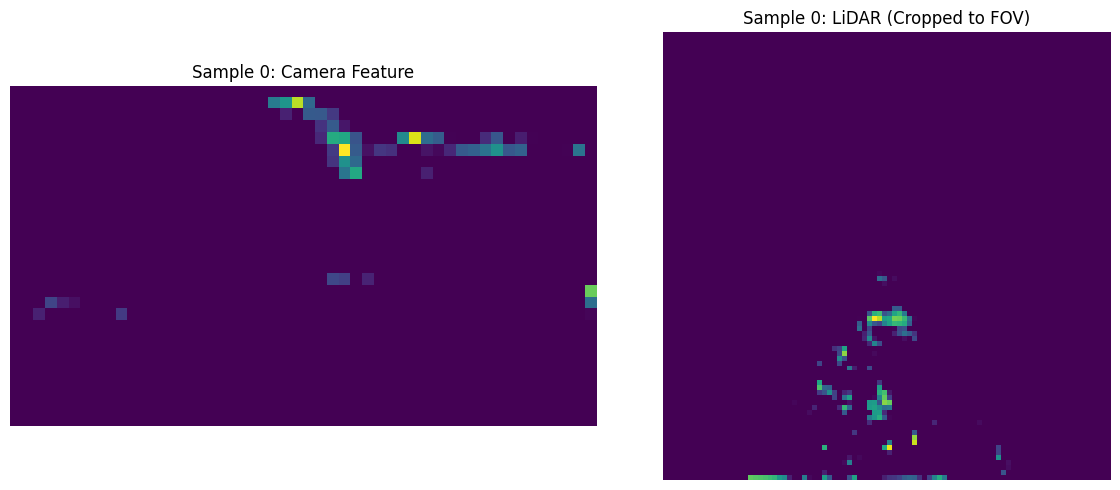

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/000868a72138448191b4092f75ed7776.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 1:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000868a72138448191b4092f75ed7776
 - Label: 1


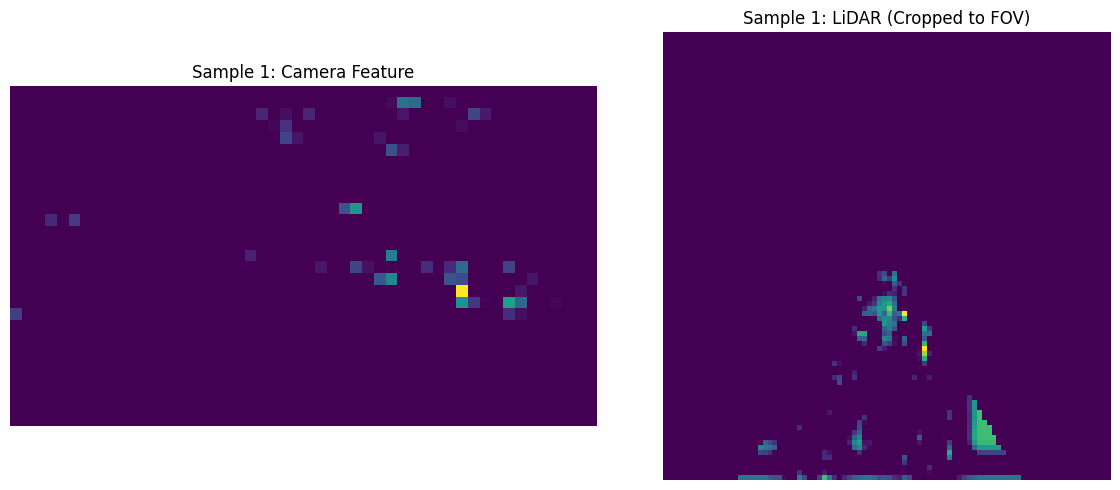

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/005d3e821c4e4e0ab03f1ea1dcbf9cc8.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 2:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 005d3e821c4e4e0ab03f1ea1dcbf9cc8
 - Label: 1


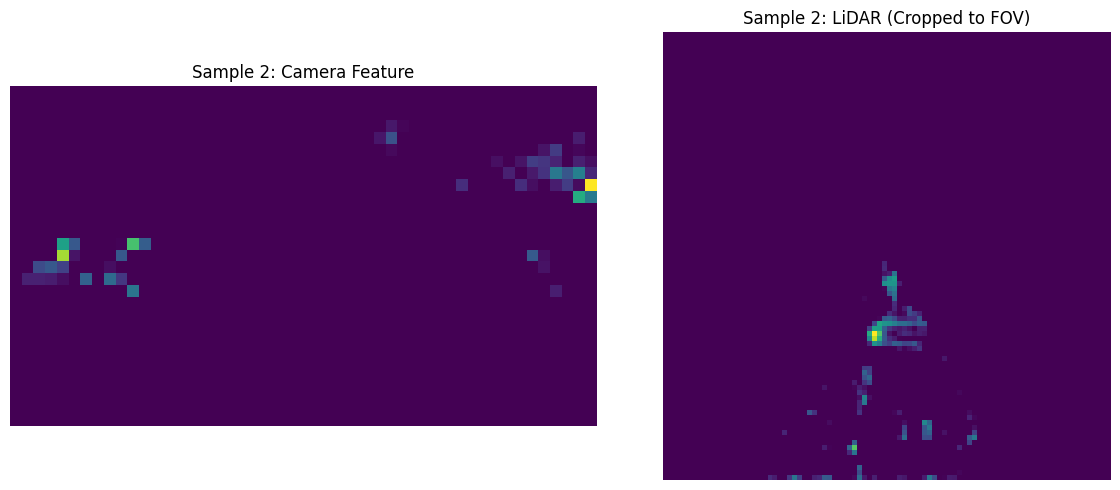

In [10]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import torch


class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path, weights_only=False)  # ← Fix for PyTorch 2.6+
            print(f"[Camera] Loaded {path}")
            if 'feat' not in data:
                print(f"⚠️  'feat' key missing in file: {path}")
                return None
            image = data['feat']
            print(f"🔍 Camera feature shape: {image.shape}")
            print(f"📄 Keys in loaded dict: {list(data.keys())}")
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.camera_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


# class TorchLidarDataset:
#     def __init__(self, lidar_files):
#         self.lidar_files = lidar_files

#     def __getitem__(self, idx):
#         path = self.lidar_files[idx]
#         try:
#             data = torch.load(path)
#             lidar = data['feat']  # Updated to match your file format
#         except Exception as e:
#             print(f"[LiDAR] Error loading {path}: {e}")
#             return None

#         return {
#             "lidar": lidar,
#             "image_id": os.path.basename(path)
#         }

#     def __len__(self):
#         return len(self.lidar_files)

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         return {
#             k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
#             for k in samples[0]
#         }


class TorchLidarDataset:
    def __init__(self, lidar_files, camera_root, bev_resolution, pc_range):
        self.lidar_files = lidar_files
        self.camera_root = camera_root
        self.bev_resolution = bev_resolution
        self.pc_range = pc_range

    def __len__(self):
        return len(self.lidar_files)
 
    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        sample_id = os.path.splitext(os.path.basename(path))[0]
        camera_path = os.path.join(self.camera_root, f"{sample_id}.pt")

        try:
            lidar_data = torch.load(path)
            lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]

            # Load camera data
            camera_data = torch.load(camera_path)
            lidar2img = camera_data['lidar2img']
            if isinstance(lidar2img, torch.Tensor):
                lidar2img = lidar2img.cpu().numpy()
            img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)

            # Crop using your existing function
            cropped_feat = crop_lidar_bev_to_camera_fov(
                lidar_feat, lidar2img, img_shape, self.bev_resolution, self.pc_range
            )

        except Exception as e:
            print(f"[LiDAR] Error loading {path} or {camera_path}: {e}")
            return None

        return {
            "lidar": cropped_feat,
            "image_id": sample_id
        }



class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f" Found {len(camera_files)} camera files in {camera_root}")
    print(f"  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f" Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f" Sample camera tokens: {cam_example}")
        print(f" Sample lidar tokens: {lidar_example}")
        print("  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files



def visualize_sample(sample, title_prefix=""):
    """
    Visualize camera feature heatmap and cropped LiDAR BEV feature heatmap.
    Args:
        sample (dict): Must contain 'image', 'lidar', and 'image_id'
    """
    # cam_feat = sample['image'].squeeze(0).mean(dim=0).cpu().numpy()  # [H, W]
    # lidar_feat = sample['lidar'].mean(dim=0).cpu().numpy()           # [H, W]
    # Camera (first channel)
    cam_feat = sample['image'].squeeze(0)[10].cpu().numpy()
    
    # LiDAR (first channel)
    lidar_feat = sample['lidar'][10].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cam_feat, cmap='viridis')
    axes[0].set_title(f"{title_prefix}Camera Feature")
    axes[0].axis('off')

    axes[1].imshow(lidar_feat, cmap='viridis')
    axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    
def main():
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    print("camera_dataset", type(camera_dataset))
    # lidar_dataset = TorchLidarDataset(matched_lidar_files)
    lidar_dataset = TorchLidarDataset(
    matched_lidar_files,
    camera_root=camera_dir,
    bev_resolution=(1.14, 1.14),  # ← Adjust if needed
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    sample = None
#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        if sample is None:
            print(f"[SKIP] Sample {i} is None.")
            continue
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
    
      # 🔍 Visualize it
        visualize_sample(sample, title_prefix=f"Sample {i}: ")
    
if __name__ == "__main__":
    main()


In [33]:
import torch
import torch.nn.functional as F

def create_bev_grid(H=90, W=90, x_range=(-51.2, 51.2), y_range=(-51.2, 51.2)):
    xs = torch.linspace(x_range[0], x_range[1], W)
    ys = torch.linspace(y_range[0], y_range[1], H)
    yy, xx = torch.meshgrid(ys, xs, indexing='ij')
    zeros = torch.zeros_like(xx)
    bev_xyz = torch.stack([xx, yy, zeros, torch.ones_like(xx)], dim=-1)  # [H, W, 4]
    return bev_xyz.view(-1, 4)  # [H*W, 4]

def project_points(bev_points, lidar2img):
    proj = (lidar2img @ bev_points.T).T  # [N, 4]
    eps = 1e-5
    proj[:, :2] = proj[:, :2] / (proj[:, 2:3] + eps)
    return proj[:, :2], proj[:, 2]

def generate_bev_from_single_camera_fpn(fpn_feats, lidar2img, image_sizes):
    """
    Args:
        fpn_feats: [4, C, H, W] FPN levels for one camera
        lidar2img: [4, 4] lidar-to-image projection matrix
        image_sizes: list of (H, W) for each level
    Returns:
        bev_map: [C, H_bev, W_bev]
    """
    assert fpn_feats.shape[0] == 4, "Expected 4 FPN levels"
    bev_grid = create_bev_grid(H=90, W=90)
    C = fpn_feats.shape[1]
    fused_bev = torch.zeros(bev_grid.shape[0], C)
    weights = torch.zeros(bev_grid.shape[0], 1)

    for lvl in range(4):
        feat = fpn_feats[lvl]  # [C, H, W]
        Hf, Wf = feat.shape[-2:]
        proj_pts, depth = project_points(bev_grid, lidar2img)

        # Scale projections to FPN level resolution (original image was 1600x928)
        proj_pts[:, 0] *= Wf / 1600.0
        proj_pts[:, 1] *= Hf / 928.0

        valid = (depth > 0) & \
                (proj_pts[:, 0] >= 0) & (proj_pts[:, 0] < Wf) & \
                (proj_pts[:, 1] >= 0) & (proj_pts[:, 1] < Hf)

        px = proj_pts[valid].long()
        sampled = feat[:, px[:, 1], px[:, 0]].T  # [N, C]

        fused_bev[valid] += sampled
        weights[valid] += 1

    weights[weights == 0] = 1
    fused_bev /= weights
    return fused_bev.view(90, 90, C).permute(2, 0, 1)  # [C, H, W]


 Found 1982 camera files in /home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT
  Found 1982 lidar files in /home/draiman/Desktop/Datasets_nuscenes/validation/lidar
 Matched 1982 files by token
🔍 Found 1982 matched samples.
[Camera FPN] Loaded 000681a060c04755a1537cf83b53ba57: torch.Size([4, 256, 15, 25])

📦 Sample 0:
 - Camera feat shape: torch.Size([4, 256, 15, 25])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000681a060c04755a1537cf83b53ba57
 - Label: 1


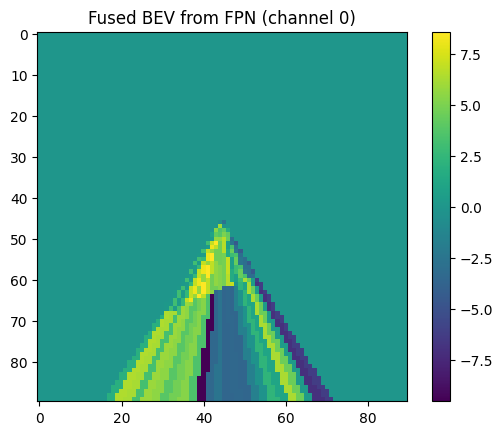

[Camera FPN] Loaded 000868a72138448191b4092f75ed7776: torch.Size([4, 256, 15, 25])

📦 Sample 1:
 - Camera feat shape: torch.Size([4, 256, 15, 25])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000868a72138448191b4092f75ed7776
 - Label: 1


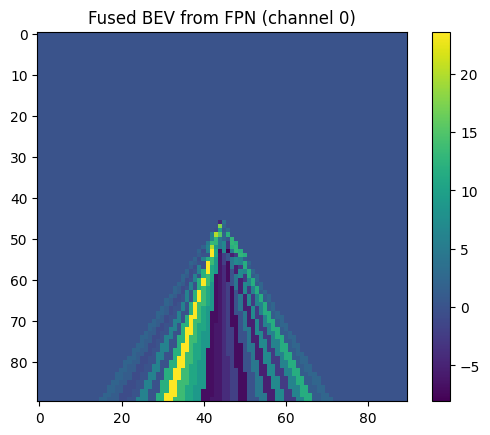

[Camera FPN] Loaded 005d3e821c4e4e0ab03f1ea1dcbf9cc8: torch.Size([4, 256, 15, 25])

📦 Sample 2:
 - Camera feat shape: torch.Size([4, 256, 15, 25])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 005d3e821c4e4e0ab03f1ea1dcbf9cc8
 - Label: 1


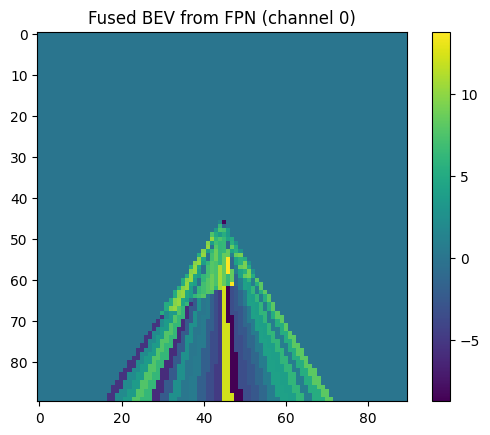

In [35]:

import os
import glob
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import matplotlib.pyplot as plt


class TorchCameraDataset:
    def __init__(self, camera_lvl0_files):
        self.camera_lvl0_files = camera_lvl0_files

    def __getitem__(self, idx):
        lvl0_path = self.camera_lvl0_files[idx]
        try:
            sample_id = os.path.basename(lvl0_path).replace("_lvl0.pt", "")
            folder = os.path.dirname(lvl0_path)

            feats = []
            target_size = None

            for lvl in range(4):
                path = os.path.join(folder, f"{sample_id}_lvl{lvl}.pt")
                data = torch.load(path, weights_only=False)
                if 'feat' not in data:
                    print(f"⚠️ 'feat' key missing in {path}")
                    return None
                feat = data['feat'].squeeze(0)  # [C, H, W]
                feats.append(feat)
                if lvl == 3:
                    target_size = feat.shape[-2:]  # (H, W)

            resized = []
            for f in feats:
                if f.shape[-2:] != target_size:
                    f = F.interpolate(f.unsqueeze(0), size=target_size, mode="bilinear", align_corners=False).squeeze(0)
                resized.append(f)

            stacked = torch.stack(resized, dim=0)  # [4, C, H, W]
            print(f"[Camera FPN] Loaded {sample_id}: {stacked.shape}")
        except Exception as e:
            print(f"[Camera] Error loading FPN levels for {lvl0_path}: {e}")
            return None

        return {
            "image": stacked,
            "image_id": sample_id
        }

    def __len__(self):
        return len(self.camera_lvl0_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


class TorchLidarDataset:
    def __init__(self, lidar_files, camera_root, bev_resolution, pc_range):
        self.lidar_files = lidar_files
        self.camera_root = camera_root
        self.bev_resolution = bev_resolution
        self.pc_range = pc_range

    def __len__(self):
        return len(self.lidar_files)
 
    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        sample_id = os.path.splitext(os.path.basename(path))[0]
        camera_path = os.path.join(self.camera_root, f"{sample_id}_lvl0.pt")


        try:
            lidar_data = torch.load(path)
            lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]

            # Load camera data
            camera_data = torch.load(camera_path)
            lidar2img = camera_data['lidar2img']
            if isinstance(lidar2img, torch.Tensor):
                lidar2img = lidar2img.cpu().numpy()
            img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)

            # Crop using your existing function
            cropped_feat = crop_lidar_bev_to_camera_fov(
                lidar_feat, lidar2img, img_shape, self.bev_resolution, self.pc_range
            )

        except Exception as e:
            print(f"[LiDAR] Error loading {path} or {camera_path}: {e}")
            return None

        return {
            "lidar": cropped_feat,
            "image_id": sample_id
        }



class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets

def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0].replace("_lvl0", ""): f
        for f in glob.glob(os.path.join(camera_root, "*_lvl0.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f" Found {len(camera_files)} camera files in {camera_root}")
    print(f"  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f" Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f" Sample camera tokens: {cam_example}")
        print(f" Sample lidar tokens: {lidar_example}")
        print("  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files


# def visualize_sample(sample, title_prefix=""):
#     """
#     Visualize FPN level 3 camera feature and cropped LiDAR BEV feature.
#     """
#     cam_feat = sample['image'][3].mean(dim=0).cpu().numpy()  # Level 3
#     lidar_feat = sample['lidar']
#     if isinstance(lidar_feat, torch.Tensor):
#         lidar_feat = lidar_feat.mean(dim=0).cpu().numpy()
#     else:
#         lidar_feat = np.nanmean(lidar_feat, axis=0)

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#     axes[0].imshow(cam_feat, cmap='viridis')
#     axes[0].set_title(f"{title_prefix}Camera FPN (lvl3)")
#     axes[0].axis('off')

#     axes[1].imshow(lidar_feat, cmap='viridis')
#     axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
#     axes[1].axis('off')

#     plt.tight_layout()
#     plt.show()


# def visualize_sample(sample, title_prefix=""):
#     """
#     Visualize all 4 FPN levels (mean across channels) and the LiDAR BEV feature.
#     """
#     fpn = sample['image']  # [4, C, H, W]
#     lidar_feat = sample['lidar']

#     if isinstance(lidar_feat, torch.Tensor):
#         lidar_feat = lidar_feat.mean(dim=0).cpu().numpy()
#     else:
#         lidar_feat = np.nanmean(lidar_feat, axis=0)

#     num_levels = fpn.shape[0]
#     fig, axes = plt.subplots(1, num_levels + 1, figsize=(4 * (num_levels + 1), 4))

#     for lvl in range(num_levels):
#         feat = fpn[lvl].mean(dim=0).cpu().numpy()  # [H, W]
#         axes[lvl].imshow(feat, cmap='viridis')
#         axes[lvl].set_title(f"{title_prefix}FPN Level {lvl}")
#         axes[lvl].axis('off')

#     axes[-1].imshow(lidar_feat, cmap='viridis')
#     axes[-1].set_title(f"{title_prefix}LiDAR (Cropped)")
#     axes[-1].axis('off')

#     plt.tight_layout()
#     plt.show()

def visualize_fused_fpn_bev(sample, camera_root):
    import os
    fpn_feats = sample['image']  # [4, C, H, W]
    sample_id = sample['image_id']
    lvl0_path = os.path.join(camera_root, f"{sample_id}_lvl0.pt")

    camera_data = torch.load(lvl0_path)
    lidar2img = camera_data['lidar2img']
    if isinstance(lidar2img, torch.Tensor):
        lidar2img = lidar2img.cpu()
    if lidar2img.ndim == 3:
        lidar2img = lidar2img[0]  # [4, 4]

    # Optional: infer image size from level 3 feature
    image_size = fpn_feats[3].shape[-2:]  # (H, W)

    bev = generate_bev_from_single_camera_fpn(fpn_feats, lidar2img, image_sizes=[image_size]*4)
    bev_np = bev[0].detach().cpu().numpy()

    import matplotlib.pyplot as plt
    plt.imshow(bev_np, cmap='viridis')
    plt.title("Fused BEV from FPN (channel 0)")
    plt.colorbar()
    plt.show()
    


def main():
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    lidar_dataset = TorchLidarDataset(
        matched_lidar_files,
        camera_root=camera_dir,
        bev_resolution=(1.14, 1.14),
        pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
    )

    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    for i in range(3):
        sample = dataset[i]
        if sample is None:
            print(f"[SKIP] Sample {i} is None.")
            continue
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
        # visualize_sample(sample, title_prefix=f"Sample {i}: ")
        visualize_fused_fpn_bev(sample, camera_root=camera_dir)



    
if __name__ == "__main__":
    main()

In [8]:
import torch
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range):
    """
    Crops LiDAR BEV features to the visible region of the front camera.
    
    Args:
        lidar_feat (torch.Tensor): LiDAR BEV feature map [C, H, W]
        lidar2img (np.ndarray): 4x4 lidar-to-image projection matrix
        img_shape (tuple): (H, W) of image
        bev_resolution (tuple): resolution per pixel (dx, dy)
        pc_range (list): point cloud range [x_min, y_min, z_min, x_max, y_max, z_max]
    
    Returns:
        torch.Tensor: Cropped LiDAR BEV features
    """
    C, H, W = lidar_feat.shape
    dx = (pc_range[3] - pc_range[0]) / W
    dy = (pc_range[4] - pc_range[1]) / H

    # Generate BEV coordinates
    xs = np.linspace(pc_range[0] + dx / 2, pc_range[3] - dx / 2, W)
    ys = np.linspace(pc_range[1] + dy / 2, pc_range[4] - dy / 2, H)
    xs, ys = np.meshgrid(xs, ys)
    zs = np.zeros_like(xs)

    points_lidar = np.stack([xs, ys, zs, np.ones_like(xs)], axis=-1).reshape(-1, 4)
    points_img = (lidar2img @ points_lidar.T).T
    points_img[:, 0] /= points_img[:, 2] + 1e-5
    points_img[:, 1] /= points_img[:, 2] + 1e-5

    img_w, img_h = img_shape[1], img_shape[0]
    valid = (points_img[:, 0] >= 0) & (points_img[:, 0] < img_w) & (points_img[:, 1] >= 0) & (points_img[:, 1] < img_h) & (points_img[:, 2] > 0)

    valid_mask = valid.reshape(H, W)
    if not isinstance(valid_mask, torch.Tensor):
        valid_mask = torch.from_numpy(valid_mask)
    valid_mask = valid_mask.float().to(lidar_feat.device)
    cropped_feat = lidar_feat * valid_mask  # zero out non-visible regions  # hard mask
    
    invalid_weight = 0.3
    # soft_mask = valid_mask * 1.0 + (1.0 - valid_mask) * invalid_weight
    # cropped_feat = lidar_feat * soft_mask                                  # soft mask
    cropped_feat = lidar_feat * valid_mask                                  # soft mask
    
    return cropped_feat








def visualize_lidar_crop(original_feat: torch.Tensor, cropped_feat: torch.Tensor, cropped_heatmap_soft: torch.Tensor):
    """
    Visualize original and cropped LiDAR BEV features as heatmaps.

    Args:
        original_feat (torch.Tensor): [C, H, W] full LiDAR BEV features
        cropped_feat (torch.Tensor): [C, H, W] cropped LiDAR BEV features
    """
    # Convert to [H, W] by averaging across channels
    original_heatmap = original_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap = cropped_feat.mean(dim=0).cpu().numpy()
    cropped_heatmap_soft = cropped_heatmap_soft.mean(dim=0).cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_heatmap, cmap='viridis')
    axes[0].set_title("Original LiDAR BEV Feature")
    axes[0].axis('off')


    axes[1].imshow(cropped_heatmap_soft, cmap='viridis')
    axes[1].set_title("Cropped to CAM_FRONT FOV")
    axes[1].axis('off')
    
    # axes[1].imshow(cropped_heatmap, cmap='viridis')
    # axes[1].set_title("Cropped to CAM_FRONT FOV")
    # axes[1].axis('off')



    
    plt.tight_layout()
    plt.show()

def test_crop(camera_path, lidar_path, bev_resolution, pc_range):
    camera_data = torch.load(camera_path, weights_only=False)
    lidar_data = torch.load(lidar_path, weights_only=False)
    lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]
    lidar2img = camera_data['lidar2img']
    img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)
    
    cropped = crop_lidar_bev_to_camera_fov(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)
    cropped_2 = crop_lidar_bev_to_camera_fov_soft(lidar_feat, lidar2img, img_shape, bev_resolution, pc_range)


    # print("✅ Cropped LiDAR shape:", cropped.shape)
    visualize_lidar_crop(lidar_feat, cropped, cropped_2)

    return cropped, cropped_2


# Define constants (example: CenterPoint settings)
bev_resolution = (1.14, 1.14)  # Meters per pixel approx. for 102.4m/90px
pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]  # From config

# Replace with real paths for testing
camera_example = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
lidar_example = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/ffec010a27b4462f86b78e2e41d14f42.pt"

# Run test
test_crop(camera_example, lidar_example, bev_resolution, pc_range)





TypeError: 'int' object is not iterable

 Found 12 camera files in /home/draiman/Desktop/Datasets_nuscenes_tiny/validation/resnet/CAM_FRONT
  Found 12 lidar files in /home/draiman/Desktop/Datasets_nuscenes_tiny/validation/lidar
 Matched 12 files by token
🔍 Found 12 matched samples.
camera_dataset <class '__main__.TorchCameraDataset'>
[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes_tiny/validation/resnet/CAM_FRONT/000bc348ae6541abac85e51b266039b5.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 0:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000bc348ae6541abac85e51b266039b5
 - Label: 1


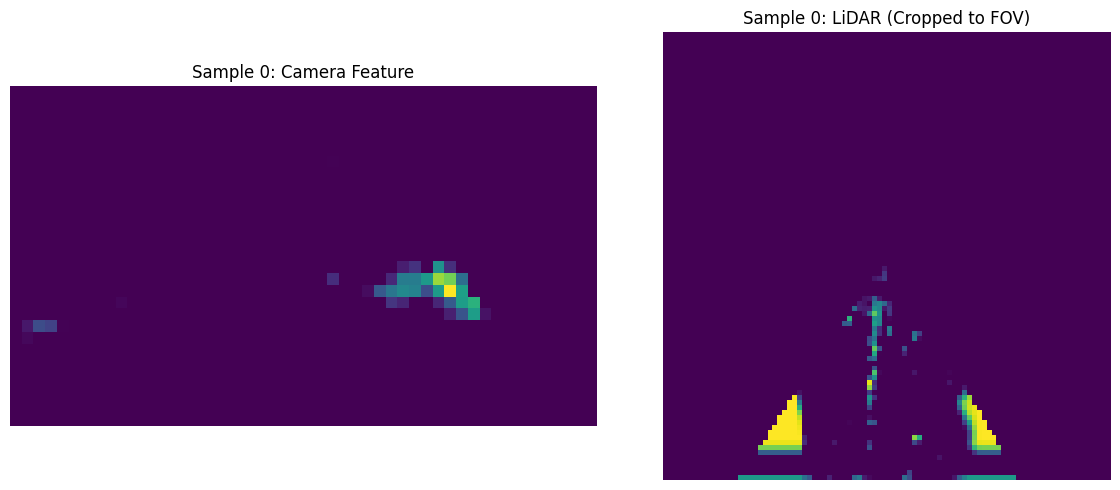

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes_tiny/validation/resnet/CAM_FRONT/000cf4dfaab54d21a7314036fde74966.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 1:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 000cf4dfaab54d21a7314036fde74966
 - Label: 1


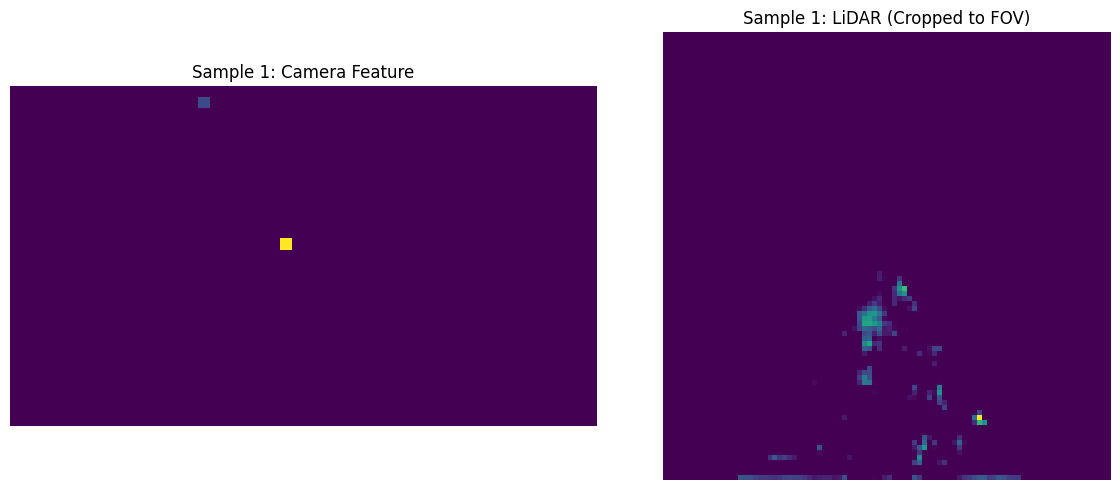

[Camera] Loaded /home/draiman/Desktop/Datasets_nuscenes_tiny/validation/resnet/CAM_FRONT/00bded4149184d25a896f3d6ebe31a80.pt
🔍 Camera feature shape: torch.Size([1, 2048, 29, 50])
📄 Keys in loaded dict: ['feat', 'lidar2img', 'img_shape', 'cam_name', 'sample_idx']

📦 Sample 2:
 - Camera feat shape: torch.Size([1, 2048, 29, 50])
 - Lidar feat shape: torch.Size([256, 90, 90])
 - Token/Image ID: 00bded4149184d25a896f3d6ebe31a80
 - Label: 1


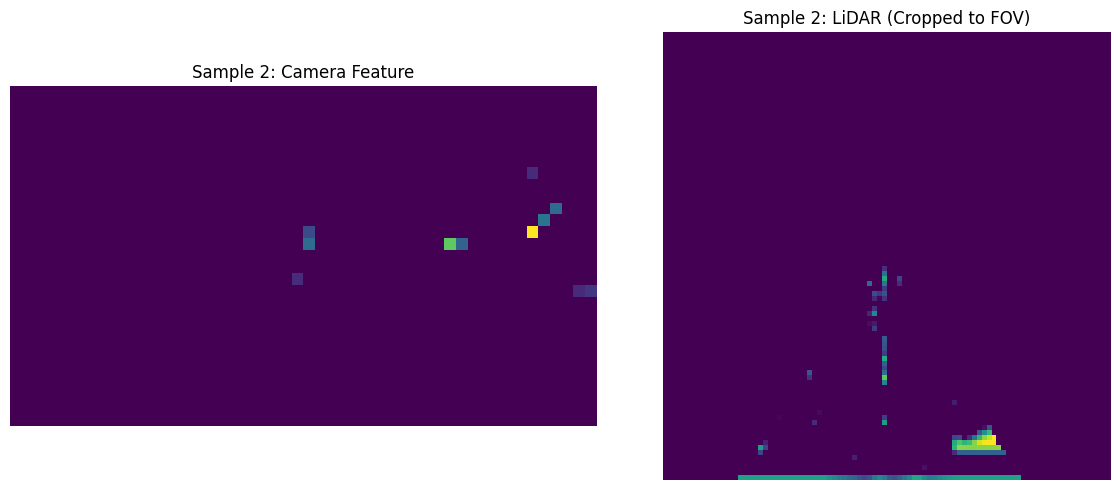

In [9]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import torch


class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path, weights_only=False)  # ← Fix for PyTorch 2.6+
            print(f"[Camera] Loaded {path}")
            if 'feat' not in data:
                print(f"⚠️  'feat' key missing in file: {path}")
                return None
            image = data['feat']
            print(f"🔍 Camera feature shape: {image.shape}")
            print(f"📄 Keys in loaded dict: {list(data.keys())}")
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.basename(path)
        }

    def __len__(self):
        return len(self.camera_files)

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        return {
            k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
            for k in samples[0]
        }


# class TorchLidarDataset:
#     def __init__(self, lidar_files):
#         self.lidar_files = lidar_files

#     def __getitem__(self, idx):
#         path = self.lidar_files[idx]
#         try:
#             data = torch.load(path)
#             lidar = data['feat']  # Updated to match your file format
#         except Exception as e:
#             print(f"[LiDAR] Error loading {path}: {e}")
#             return None

#         return {
#             "lidar": lidar,
#             "image_id": os.path.basename(path)
#         }

#     def __len__(self):
#         return len(self.lidar_files)

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         return {
#             k: torch.stack([s[k] for s in samples]) if isinstance(samples[0][k], torch.Tensor) else [s[k] for s in samples]
#             for k in samples[0]
#         }


class TorchLidarDataset:
    def __init__(self, lidar_files, camera_root, bev_resolution, pc_range):
        self.lidar_files = lidar_files
        self.camera_root = camera_root
        self.bev_resolution = bev_resolution
        self.pc_range = pc_range

    def __len__(self):
        return len(self.lidar_files)
 
    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        sample_id = os.path.splitext(os.path.basename(path))[0]
        camera_path = os.path.join(self.camera_root, f"{sample_id}.pt")

        try:
            lidar_data = torch.load(path, weights_only=True)
            lidar_feat = lidar_data['feat'].squeeze(0)  # [C, H, W]

            # Load camera data
            camera_data = torch.load(camera_path, weights_only=True)
            lidar2img = camera_data['lidar2img']
            if isinstance(lidar2img, torch.Tensor):
                lidar2img = lidar2img.cpu().numpy()
            img_shape = tuple(camera_data['img_shape'][0])[:2]  # (H, W)

            # Crop using your existing function
            cropped_feat = crop_lidar_bev_to_camera_fov(
                lidar_feat, lidar2img, img_shape, self.bev_resolution, self.pc_range
            )

        except Exception as e:
            print(f"[LiDAR] Error loading {path} or {camera_path}: {e}")
            return None

        return {
            "lidar": cropped_feat,
            "image_id": sample_id
        }



class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]

    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {**cam_sample, **lidar_sample, "label": 1}

    def __len__(self):
        return min(len(self.camera_dataset), len(self.lidar_dataset))

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        batch = self.camera_dataset.collater(samples)
        batch.update({"lidar": torch.stack([s["lidar"] for s in samples])})
        batch["label"] = torch.tensor([s["label"] for s in samples])
        return batch


class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    print(f" Found {len(camera_files)} camera files in {camera_root}")
    print(f"  Found {len(lidar_files)} lidar files in {lidar_root}")

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    print(f" Matched {len(matched_keys)} files by token")

    if len(matched_keys) == 0:
        cam_example = list(camera_files.keys())[:5]
        lidar_example = list(lidar_files.keys())[:5]
        print(f" Sample camera tokens: {cam_example}")
        print(f" Sample lidar tokens: {lidar_example}")
        print("  Check if filenames match exactly (excluding '.pt')")

    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files



def visualize_sample(sample, title_prefix=""):
    """
    Visualize camera feature heatmap and cropped LiDAR BEV feature heatmap.
    Args:
        sample (dict): Must contain 'image', 'lidar', and 'image_id'
    """
    # cam_feat = sample['image'].squeeze(0).mean(dim=0).cpu().numpy()  # [H, W]
    # lidar_feat = sample['lidar'].mean(dim=0).cpu().numpy()           # [H, W]
    # Camera (first channel)
    cam_feat = sample['image'].squeeze(0)[10].cpu().numpy()
    
    # LiDAR (first channel)
    lidar_feat = sample['lidar'][10].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cam_feat, cmap='viridis')
    axes[0].set_title(f"{title_prefix}Camera Feature")
    axes[0].axis('off')

    axes[1].imshow(lidar_feat, cmap='viridis')
    axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    
def main():
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes_tiny/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes_tiny/validation/lidar"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

    print(f"🔍 Found {len(matched_camera_files)} matched samples.")

    camera_dataset = TorchCameraDataset(matched_camera_files)
    print("camera_dataset", type(camera_dataset))
    # lidar_dataset = TorchLidarDataset(matched_lidar_files)
    lidar_dataset = TorchLidarDataset(
    matched_lidar_files,
    camera_root=camera_dir,
    bev_resolution=(1.14, 1.14),  # ← Adjust if needed
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    sample = None
#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        if sample is None:
            print(f"[SKIP] Sample {i} is None.")
            continue
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
    
      # 🔍 Visualize it
        visualize_sample(sample, title_prefix=f"Sample {i}: ")
    
if __name__ == "__main__":
    main()


In [5]:
import os
import glob
import torch
from torch.utils.data import ConcatDataset
from PIL import Image



class TorchCameraDataset:
    def __init__(self, camera_files):
        self.camera_files = camera_files

    def __getitem__(self, idx):
        path = self.camera_files[idx]
        try:
            data = torch.load(path)
            image = data['feat']  # Updated to match your file format
        except Exception as e:
            print(f"[Camera] Error loading {path}: {e}")
            return None

        return {
            "image": image,
            "image_id": os.path.splitext(os.path.basename(path))[0]

        }

    def __len__(self):
        return len(self.camera_files)



class TorchLidarDataset:
    def __init__(self, lidar_files):
        self.lidar_files = lidar_files

    def __getitem__(self, idx):
        path = self.lidar_files[idx]
        try:
            data = torch.load(path)
            lidar = data['feat']  # Updated to match your file format
        except Exception as e:
            print(f"[LiDAR] Error loading {path}: {e}")
            return None

        return {
            "lidar": lidar,
            "image_id": os.path.splitext(os.path.basename(path))[0]
        }

    def __len__(self):
        return len(self.lidar_files)





class WrappedConcatDataset(ConcatDataset):
    def __init__(self, datasets):
        assert len(datasets) == 2
        super().__init__(datasets)
        self.camera_dataset = datasets[0]
        self.lidar_dataset = datasets[1]
        self.length = min(len(self.camera_dataset), len(self.lidar_dataset))

    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        if idx >= len(self.camera_dataset) or idx >= len(self.lidar_dataset):
            return None
        cam_sample = self.camera_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        return {
            **cam_sample,
            **lidar_sample,
            "label": 1  # or use some logic if label varies
        }

    def collater(self, samples):   
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}

        output = {}
        keys = samples[0].keys()
        
        for k in keys:
            values = [s[k] for s in samples]
            first = values[0]

            if isinstance(first, torch.Tensor):
                output[k] = torch.stack(values)
            elif isinstance(first, (int, float)):
                output[k] = torch.tensor(values)
            else:
                output[k] = values

        return output

# creates train/val/test splits from config
class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.config = cfg

    def build_datasets(self):
        build_info = self.config.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            if split in self.config.run_cfg.train_splits + self.config.run_cfg.valid_splits + self.config.run_cfg.test_splits:
                camera_root = build_info["camera"][split].storage
                lidar_root = build_info["lidar"][split].storage

                matched_camera_files, matched_lidar_files = get_matched_files(camera_root, lidar_root)

                camera_dataset = TorchCameraDataset(matched_camera_files)
                lidar_dataset = TorchLidarDataset(matched_lidar_files)

                datasets[split] = WrappedConcatDataset([camera_dataset, lidar_dataset])

        return datasets


def get_matched_files(camera_root, lidar_root):
    camera_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(camera_root, "*.pt"))
    }
    lidar_files = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in glob.glob(os.path.join(lidar_root, "*.pt"))
    }

    matched_keys = sorted(set(camera_files) & set(lidar_files))
    matched_camera_files = [camera_files[k] for k in matched_keys]
    matched_lidar_files = [lidar_files[k] for k in matched_keys]

    return matched_camera_files, matched_lidar_files

def visualize_sample(sample, title_prefix=""):
    """
    Visualize camera feature heatmap and cropped LiDAR BEV feature heatmap.
    Args:
        sample (dict): Must contain 'image', 'lidar', and 'image_id'
    """
    # cam_feat = sample['image'].squeeze(0).mean(dim=0).cpu().numpy()  # [H, W]
    # lidar_feat = sample['lidar'].mean(dim=0).cpu().numpy()           # [H, W]
    # Camera (first channel)
    cam_feat = sample['image'].squeeze(0)[10].cpu().numpy()
    
    # LiDAR (first channel)
    lidar_feat = sample['lidar'][10].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cam_feat, cmap='viridis')
    axes[0].set_title(f"{title_prefix}Camera Feature")
    axes[0].axis('off')

    axes[1].imshow(lidar_feat, cmap='viridis')
    axes[1].set_title(f"{title_prefix}LiDAR (Cropped to FOV)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    
def main():
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"
    lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"

    matched_camera_files, matched_lidar_files = get_matched_files(camera_dir, lidar_dir)

#     print(f"🔍 Found {len(matched_camera_files)} matched samples.")

#     camera_dataset = TorchCameraDataset(matched_camera_files)
#     print("camera_dataset", type(camera_dataset))
#     # lidar_dataset = TorchLidarDataset(matched_lidar_files)
#     lidar_dataset = TorchLidarDataset(
#     matched_lidar_files,
#     camera_root=camera_dir,
#     bev_resolution=(1.14, 1.14),  # ← Adjust if needed
#     pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
# )
    camera_dataset = TorchCameraDataset(matched_camera_files)
    lidar_dataset = TorchLidarDataset(matched_lidar_files)

    dataset = WrappedConcatDataset([camera_dataset, lidar_dataset])
    sample = None
#    Show a few matched samples
    for i in range(3):
        sample = dataset[i]
        if sample is None:
            print(f"[SKIP] Sample {i} is None.")
            continue
        print(f"\n📦 Sample {i}:")
        print(f" - Camera feat shape: {sample['image'].shape}")
        print(f" - Lidar feat shape: {sample['lidar'].shape}")
        print(f" - Token/Image ID: {sample['image_id']}")
        print(f" - Label: {sample['label']}")
    
      # 🔍 Visualize it
        visualize_sample(sample, title_prefix=f"Sample {i}: ")
    
if __name__ == "__main__":
    main()


[Camera] Error loading /home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/000681a060c04755a1537cf83b53ba57.pt: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([_reconstruct])` or the `torch.serialization.safe_globals([_reconstruct])` context manager to allowlist this global if you t

Image shape: [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)] <class 'list'>


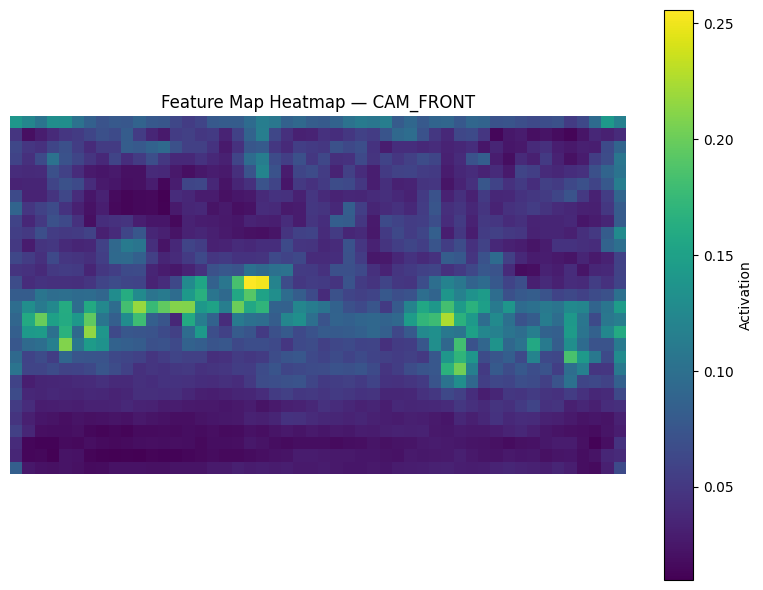

image 1 
Image shape: (900, 1600) <class 'tuple'>


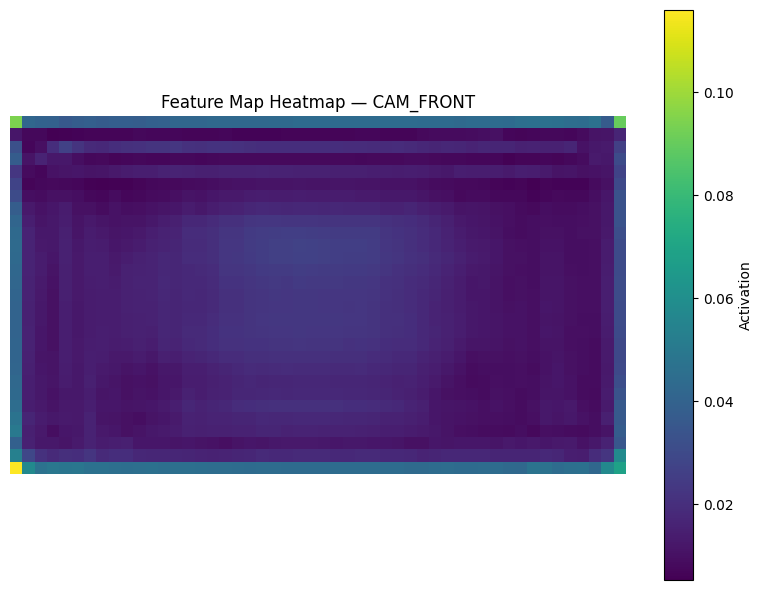

In [6]:
import torch
import matplotlib.pyplot as plt
import os

# Path to your .pt file
# camera_example = "/home/draiman/Desktop/Datasets/validation/resnet/CAM_FRONT/ffec010a27b4462f86b78e2e41d14f42.pt"
camera_example = "/data/train_/resnet/CAM_FRONT/978c3654ef014916bd77c73b1b796060.pt"



# Load the file
camera_data = torch.load(camera_example, map_location='cpu')

# Extract and preprocess features
feat = camera_data['feat'].squeeze(0)  # shape becomes [C, H, W]
heatmap = feat.mean(dim=0).numpy()     # average over channels → shape [H, W]
print("Image shape:", camera_data['img_shape'], type(camera_data['img_shape']))
# Plotting
plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='viridis')
plt.title(f"Feature Map Heatmap — {camera_data.get('cam_name', 'Unknown Camera')}")
plt.axis('off')
plt.colorbar(label="Activation")
plt.tight_layout()
plt.show()

print("image 1 ")

camera_example = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/9c1fc0d8c93b4a8584cc4f41d2863667.pt"

# Load the file
# camera_data = torch.load(camera_example, map_location='cpu')
camera_data = torch.load(camera_example, map_location='cpu', weights_only=False)

# Extract and preprocess features
feat = camera_data['feat'].squeeze(0)  # shape becomes [C, H, W]
heatmap = feat.mean(dim=0).numpy()     # average over channels → shape [H, W]
print("Image shape:", camera_data['img_shape'], type(camera_data['img_shape']))
# Plotting
plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='viridis')
plt.title(f"Feature Map Heatmap — {camera_data.get('cam_name', 'Unknown Camera')}")
plt.axis('off')
plt.colorbar(label="Activation")
plt.tight_layout()
plt.show()
